# Credit Card Delinquency Prediction - Exploratory Data Analysis (EDA)

## Project Overview

This notebook performs exploratory data analysis (EDA) on a credit card delinquency dataset provided as part of the Tata iQ × Forage AI Transformation Virtual Experience Program.

### Objectives

- Understand the dataset structure
- Assess data quality
- Identify missing values and inconsistencies
- Explore customer behavior
- Analyze relationships between financial variables and delinquency
- Engineer features for predictive modeling

# **Part 1: Setup & Dataset Overview**

In [1]:
# Import libraries

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
# Create folder for saving figures

os.makedirs("images", exist_ok=True)

print("Images folder created.")

Images folder created.


In [3]:
# Load dataset

df = pd.read_excel("/content/Delinquency_prediction_dataset.xlsx")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
# Display first five records

df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.00,398.00,0.39,3,0,16310.00,0.32,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.00,493.00,0.31,6,1,17401.00,0.20,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.00,500.00,0.36,0,0,13761.00,0.30,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.00,413.00,0.37,3,0,88778.00,0.26,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.00,487.00,0.23,2,0,13316.00,0.51,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [5]:
# Display dataset dimensions

rows, columns = df.shape

print(f"Rows    : {rows}")
print(f"Columns : {columns}")

Rows    : 500
Columns : 19


In [6]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [7]:
# Summary statistics

df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,500,500,CUST0500,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,500.00,NaN,NaN,NaN,46.27,16.19,18.00,33.00,46.50,59.25,74.00
Income,461.00,NaN,NaN,NaN,108379.89,53662.72,15404.00,62295.00,107658.00,155734.00,199943.00
Credit_Score,498.00,NaN,NaN,NaN,577.72,168.88,301.00,418.25,586.00,727.25,847.00
Credit_Utilization,500.00,NaN,NaN,NaN,0.49,0.20,0.05,0.36,0.49,0.63,1.03
Missed_Payments,500.00,NaN,NaN,NaN,2.97,1.95,0.00,1.00,3.00,5.00,6.00
Delinquent_Account,500.00,NaN,NaN,NaN,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Loan_Balance,471.00,NaN,NaN,NaN,48654.43,29395.54,612.00,23716.50,45776.00,75546.50,99620.00
Debt_to_Income_Ratio,500.00,NaN,NaN,NaN,0.30,0.09,0.10,0.23,0.30,0.36,0.55
Employment_Status,500,6,Unemployed,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Dataset overview

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Number of Records : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

DATASET OVERVIEW
Number of Records : 500
Number of Columns : 19


In [9]:
# Display column names

for column in df.columns:
    print(column)

Customer_ID
Age
Income
Credit_Score
Credit_Utilization
Missed_Payments
Delinquent_Account
Loan_Balance
Debt_to_Income_Ratio
Employment_Status
Account_Tenure
Credit_Card_Type
Location
Month_1
Month_2
Month_3
Month_4
Month_5
Month_6


In [10]:
# Display data types

data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

data_types

,Column,Data Type
0,Customer_ID,object
1,Age,int64
2,Income,float64
3,Credit_Score,float64
4,Credit_Utilization,float64
5,Missed_Payments,int64
6,Delinquent_Account,int64
7,Loan_Balance,float64
8,Debt_to_Income_Ratio,float64
9,Employment_Status,object


In [11]:
# Separate numerical and categorical features

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features")
print(numerical_columns)

print()

print("Categorical Features")
print(categorical_columns)

Numerical Features
['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Delinquent_Account', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure']

Categorical Features
['Customer_ID', 'Employment_Status', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']


In [12]:
# Dataset summary

summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

summary

,Column,Data Type,Missing Values,Unique Values
0,Customer_ID,object,0,500
1,Age,int64,0,57
2,Income,float64,39,271
3,Credit_Score,float64,2,234
4,Credit_Utilization,float64,0,492
5,Missed_Payments,int64,0,7
6,Delinquent_Account,int64,0,2
7,Loan_Balance,float64,29,300
8,Debt_to_Income_Ratio,float64,0,487
9,Employment_Status,object,0,6


In [13]:
# Save dataset summary

summary.to_csv(
    "dataset_summary.csv",
    index=False
)

print("Dataset summary saved.")

Dataset summary saved.


In [14]:
# Check duplicate records

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [15]:
# Check duplicate customer IDs

duplicate_customer_ids = df["Customer_ID"].duplicated().sum()

print(f"Duplicate Customer IDs : {duplicate_customer_ids}")

Duplicate Customer IDs : 0


# **Part 2: Missing Value Analysis & Data Quality**

In [16]:
# Count missing values

missing_values = df.isnull().sum()

missing_percentage = (
    missing_values / len(df)
) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage.round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
]

missing_summary.sort_values(
    by="Missing Values",
    ascending=False,
    inplace=True
)

missing_summary

,Missing Values,Percentage (%)
Income,39,7.80
Loan_Balance,29,5.80
Credit_Score,2,0.40


In [17]:
# Save missing values summary

missing_summary.to_csv(
    "missing_values_summary.csv"
)

print("Missing value summary saved.")

Missing value summary saved.


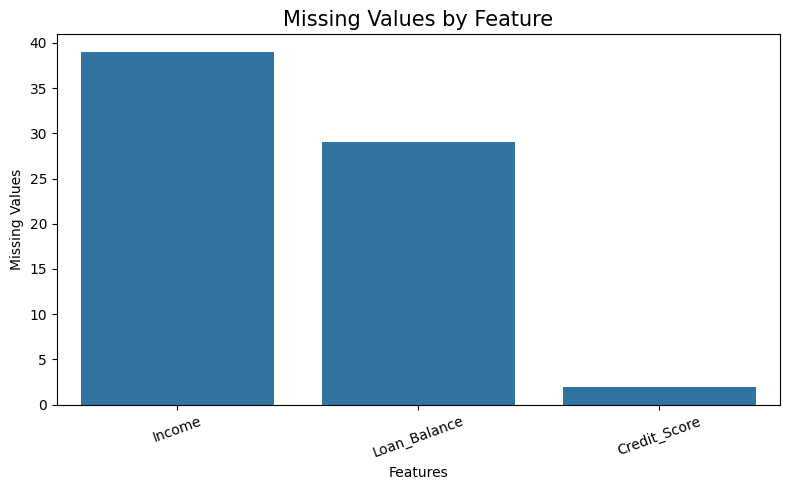

In [18]:
# Plot missing values

plt.figure(figsize=(8,5))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing Values"]
)

plt.title("Missing Values by Feature", fontsize=15)

plt.xlabel("Features")

plt.ylabel("Missing Values")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "images/missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# Display missing value percentages

missing_summary["Percentage (%)"]

,Percentage (%)
Income,7.80
Loan_Balance,5.80
Credit_Score,0.40


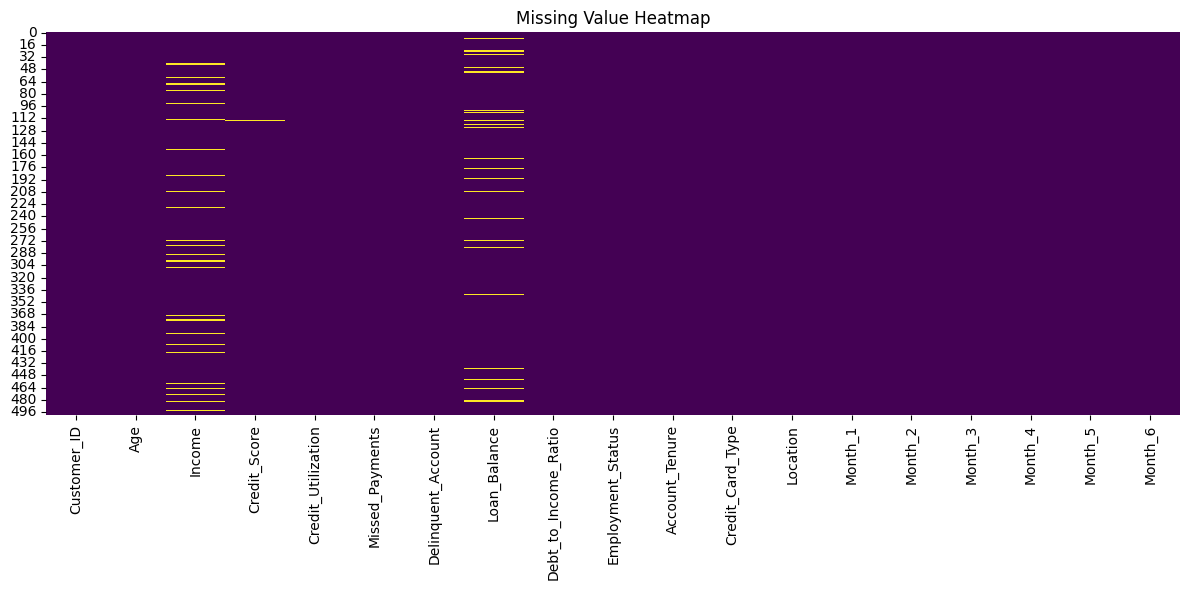

In [20]:
# Plot missing value heatmap

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.tight_layout()

plt.savefig(
    "images/missing_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Check important features

important_features = [
    "Income",
    "Loan_Balance",
    "Credit_Score",
    "Credit_Utilization",
    "Debt_to_Income_Ratio"
]

for column in important_features:

    if column in df.columns:

        print(
            f"{column} : {df[column].isnull().sum()}"
        )

Income : 39
Loan_Balance : 29
Credit_Score : 2
Credit_Utilization : 0
Debt_to_Income_Ratio : 0


In [22]:
# Calculate complete records

complete_records = df.dropna().shape[0]

percentage_complete = (
    complete_records / len(df)
) * 100

print(f"Complete Records : {complete_records}")

print(f"Percentage : {percentage_complete:.2f}%")

Complete Records : 436
Percentage : 87.20%


In [23]:
# Create data quality summary

quality_summary = pd.DataFrame({
    "Check": [
        "Total Records",
        "Duplicate Records",
        "Duplicate Customer IDs",
        "Features with Missing Values",
        "Complete Records"
    ],
    "Result": [
        len(df),
        duplicates,
        duplicate_customer_ids,
        missing_summary.shape[0],
        complete_records
    ]
})

quality_summary

,Check,Result
0,Total Records,500
1,Duplicate Records,0
2,Duplicate Customer IDs,0
3,Features with Missing Values,3
4,Complete Records,436


In [24]:
# Save data quality summary

quality_summary.to_csv(
    "data_quality_summary.csv",
    index=False
)

print("Data quality summary saved.")

Data quality summary saved.


In [25]:
# Display initial observations

print("=" * 60)
print("INITIAL DATA QUALITY OBSERVATIONS")
print("=" * 60)

print("""
1. Missing values are present in Income,
   Loan_Balance and Credit_Score.

2. Duplicate records should be checked
   before model development.

3. Critical financial variables require
   preprocessing before predictive modeling.

4. Numerical and categorical variables
   are available for feature engineering.
""")

INITIAL DATA QUALITY OBSERVATIONS

1. Missing values are present in Income,
   Loan_Balance and Credit_Score.

2. Duplicate records should be checked
   before model development.

3. Critical financial variables require
   preprocessing before predictive modeling.

4. Numerical and categorical variables
   are available for feature engineering.



# **Part 3: Target Variable & Numerical Data Analysis**

In [26]:
# Display target variable distribution

target_distribution = df["Delinquent_Account"].value_counts()

print(target_distribution)

Delinquent_Account
0    420
1     80
Name: count, dtype: int64


In [27]:
# Display target variable percentage

target_percentage = (
    df["Delinquent_Account"]
    .value_counts(normalize=True)
    * 100
)

print(target_percentage.round(2))

Delinquent_Account
0   84.00
1   16.00
Name: proportion, dtype: float64


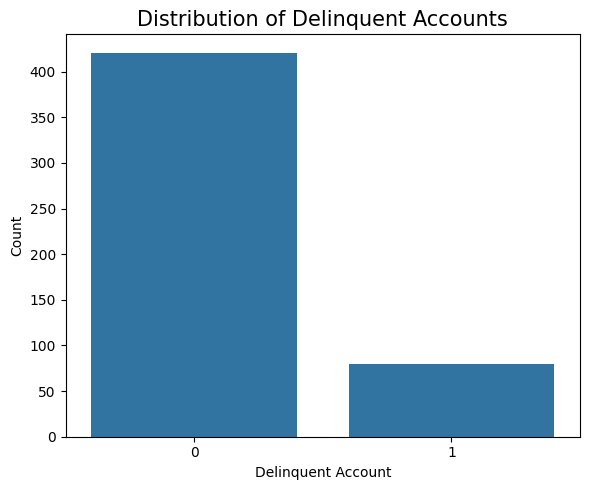

In [28]:
# Plot target variable distribution

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Delinquent_Account"
)

plt.title("Distribution of Delinquent Accounts", fontsize=15)

plt.xlabel("Delinquent Account")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "images/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# Summary statistics for numerical variables

df.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.00,461.00,498.00,500.00,500.00,500.00,471.00,500.00,500.00
mean,46.27,108379.89,577.72,0.49,2.97,0.16,48654.43,0.30,9.74
std,16.19,53662.72,168.88,0.20,1.95,0.37,29395.54,0.09,5.92
min,18.00,15404.00,301.00,0.05,0.00,0.00,612.00,0.10,0.00
25%,33.00,62295.00,418.25,0.36,1.00,0.00,23716.50,0.23,5.00
50%,46.50,107658.00,586.00,0.49,3.00,0.00,45776.00,0.30,10.00
75%,59.25,155734.00,727.25,0.63,5.00,0.00,75546.50,0.36,15.00
max,74.00,199943.00,847.00,1.03,6.00,1.00,99620.00,0.55,19.00


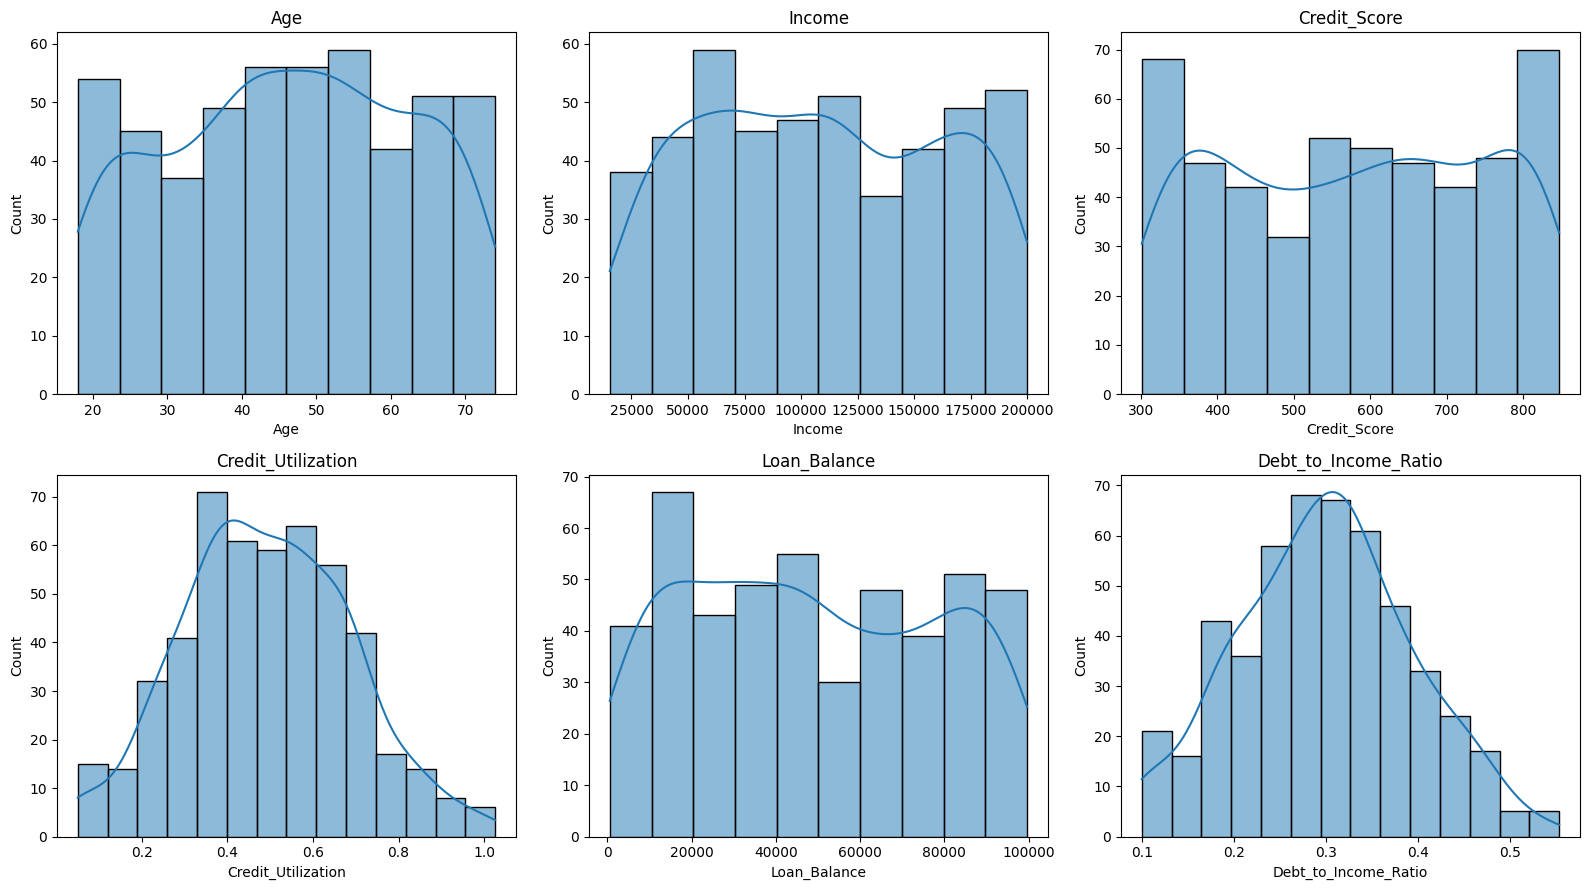

In [30]:
# Plot numerical feature distributions

numerical_features = [
    "Age",
    "Income",
    "Credit_Score",
    "Credit_Utilization",
    "Loan_Balance",
    "Debt_to_Income_Ratio"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes = axes.flatten()

for ax, column in zip(axes, numerical_features):

    sns.histplot(
        df[column],
        kde=True,
        ax=ax
    )

    ax.set_title(column)

plt.tight_layout()

plt.savefig(
    "images/numerical_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

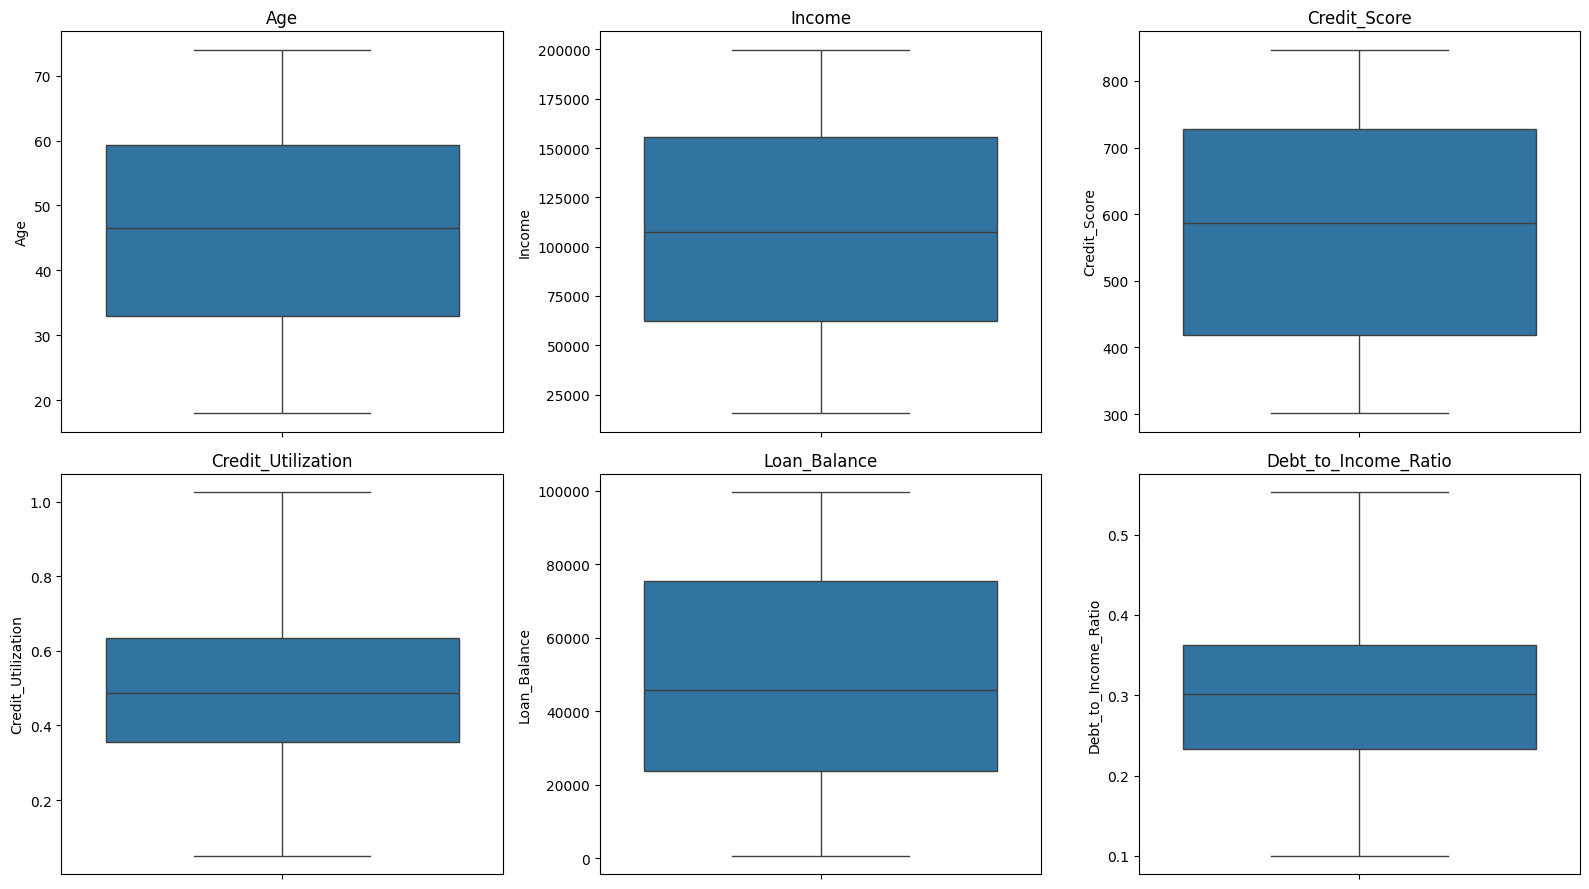

In [31]:
# Plot boxplots for numerical features

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes = axes.flatten()

for ax, column in zip(axes, numerical_features):

    sns.boxplot(
        y=df[column],
        ax=ax
    )

    ax.set_title(column)

plt.tight_layout()

plt.savefig(
    "images/all_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

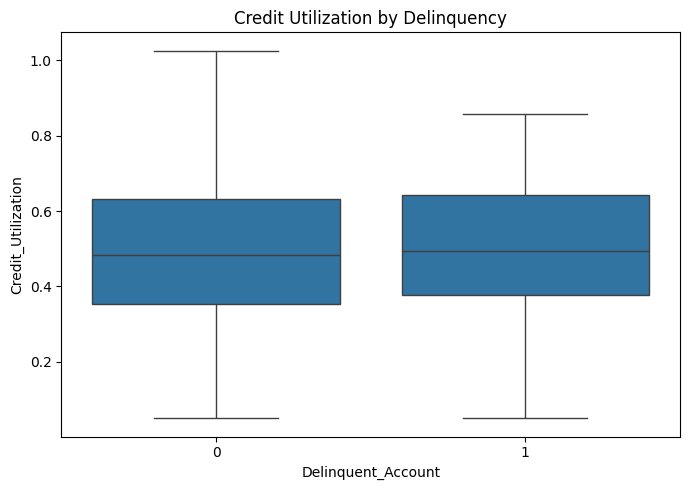

In [32]:
# Compare credit utilization by delinquency status

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Delinquent_Account",
    y="Credit_Utilization"
)

plt.title("Credit Utilization by Delinquency")

plt.tight_layout()

plt.savefig(
    "images/credit_utilization_delinquency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

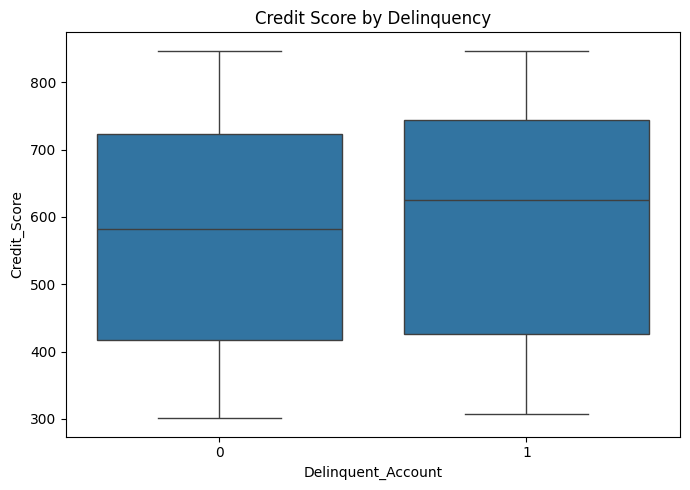

In [33]:
# Compare credit score by delinquency status

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Delinquent_Account",
    y="Credit_Score"
)

plt.title("Credit Score by Delinquency")

plt.tight_layout()

plt.savefig(
    "images/credit_score_delinquency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

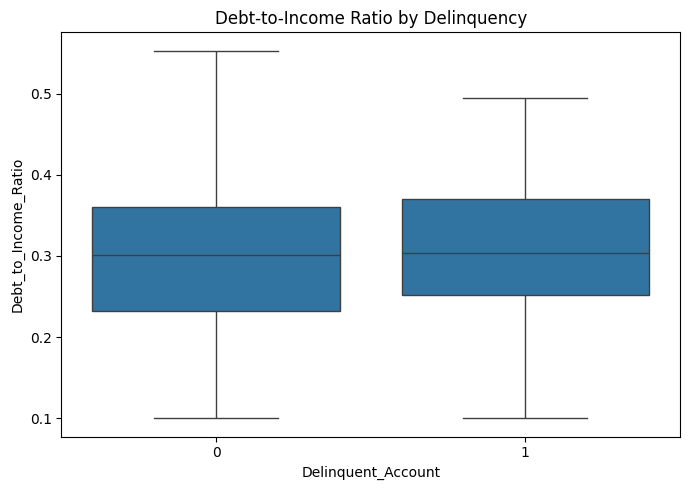

In [34]:
# Compare debt-to-income ratio by delinquency status

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Delinquent_Account",
    y="Debt_to_Income_Ratio"
)

plt.title("Debt-to-Income Ratio by Delinquency")

plt.tight_layout()

plt.savefig(
    "images/dti_delinquency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# Compute correlation matrix

correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
Age,1.00,0.01,-0.03,0.02,-0.02,0.02,-0.05,-0.01,0.02
Income,0.01,1.00,0.07,0.04,-0.00,0.05,-0.05,-0.06,-0.00
Credit_Score,-0.03,0.07,1.00,-0.02,-0.01,0.03,-0.02,-0.01,-0.04
Credit_Utilization,0.02,0.04,-0.02,1.00,0.02,0.03,-0.05,-0.06,0.07
Missed_Payments,-0.02,-0.00,-0.01,0.02,1.00,-0.03,-0.02,0.00,-0.10
Delinquent_Account,0.02,0.05,0.03,0.03,-0.03,1.00,-0.00,0.03,-0.04
Loan_Balance,-0.05,-0.05,-0.02,-0.05,-0.02,-0.00,1.00,0.06,0.05
Debt_to_Income_Ratio,-0.01,-0.06,-0.01,-0.06,0.00,0.03,0.06,1.00,0.03
Account_Tenure,0.02,-0.00,-0.04,0.07,-0.10,-0.04,0.05,0.03,1.00


In [36]:
# Correlation with target variable

target_correlation = (
    correlation_matrix["Delinquent_Account"]
    .drop("Delinquent_Account")
    .sort_values(ascending=False)
)

target_correlation

,Delinquent_Account
Income,0.05
Credit_Score,0.03
Debt_to_Income_Ratio,0.03
Credit_Utilization,0.03
Age,0.02
Loan_Balance,-0.00
Missed_Payments,-0.03
Account_Tenure,-0.04


In [37]:
# Save feature correlation ranking

target_correlation.to_csv(
    "feature_correlation_ranking.csv"
)

print("Correlation table saved.")

Correlation table saved.


# **Part 4: Correlation & Categorical Feature Analysis**

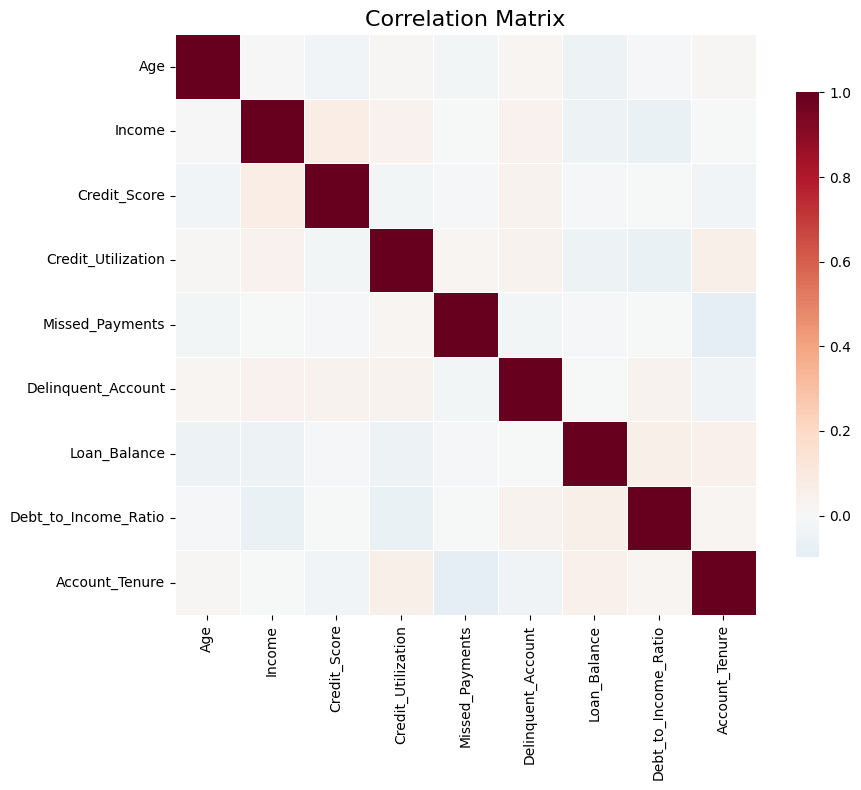

In [38]:
# Plot correlation heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=16)

plt.tight_layout()

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

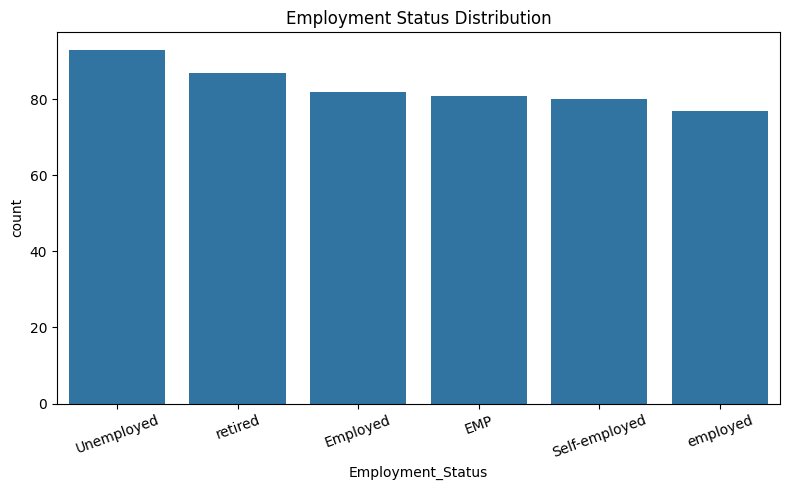

In [39]:
# Plot employment status distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Employment_Status",
    order=df["Employment_Status"].value_counts().index
)

plt.title("Employment Status Distribution")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "images/employment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
# Compare employment status with delinquency

employment_risk = pd.crosstab(
    df["Employment_Status"],
    df["Delinquent_Account"],
    normalize="index"
) * 100

employment_risk

Delinquent_Account,0,1
Employment_Status,,
EMP,85.19,14.81
Employed,81.71,18.29
Self-employed,83.75,16.25
Unemployed,80.65,19.35
employed,84.42,15.58
retired,88.51,11.49


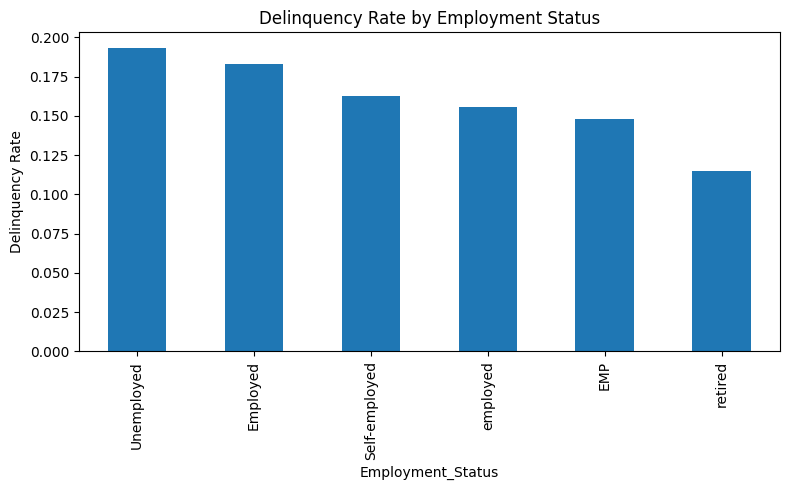

In [41]:
# Plot delinquency rate by employment status

employment_rate = (
    df.groupby("Employment_Status")
      ["Delinquent_Account"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

employment_rate.plot(kind="bar")

plt.ylabel("Delinquency Rate")

plt.title("Delinquency Rate by Employment Status")

plt.tight_layout()

plt.savefig(
    "images/employment_delinquency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

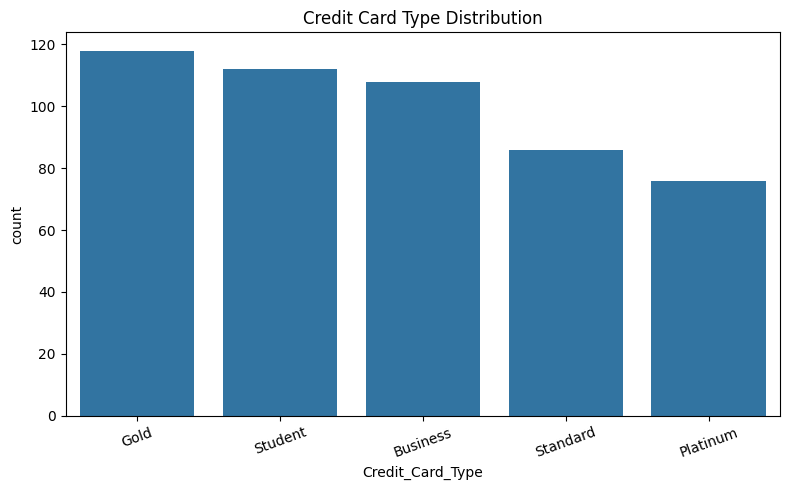

In [42]:
# Plot credit card type distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Credit_Card_Type",
    order=df["Credit_Card_Type"].value_counts().index
)

plt.title("Credit Card Type Distribution")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "images/card_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
# Compare credit card type with delinquency

card_risk = pd.crosstab(
    df["Credit_Card_Type"],
    df["Delinquent_Account"],
    normalize="index"
) * 100

card_risk

Delinquent_Account,0,1
Credit_Card_Type,,
Business,78.70,21.30
Gold,85.59,14.41
Platinum,88.16,11.84
Standard,87.21,12.79
Student,82.14,17.86


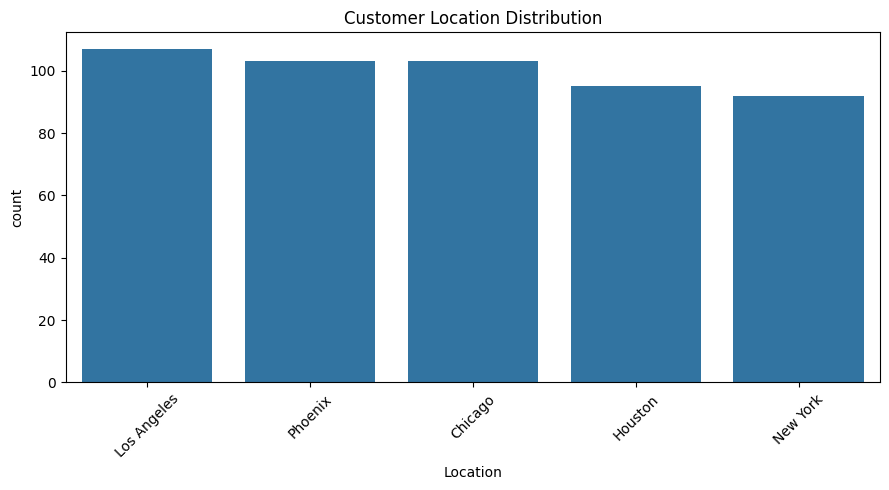

In [44]:
# Plot location distribution

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Location",
    order=df["Location"].value_counts().index
)

plt.title("Customer Location Distribution")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "images/location_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# Compare location with delinquency

location_risk = pd.crosstab(
    df["Location"],
    df["Delinquent_Account"],
    normalize="index"
) * 100

location_risk

Delinquent_Account,0,1
Location,,
Chicago,85.44,14.56
Houston,83.16,16.84
Los Angeles,80.37,19.63
New York,88.04,11.96
Phoenix,83.50,16.50


In [46]:
# Display payment history tables

payment_months = [
    "Month_1",
    "Month_2",
    "Month_3",
    "Month_4",
    "Month_5",
    "Month_6"
]

for month in payment_months:

    print("\n", "="*50)
    print(month)
    print("="*50)

    display(
        pd.crosstab(
            df[month],
            df["Delinquent_Account"]
        )
    )


Month_1


Delinquent_Account,0,1
Month_1,,
Late,141,18
Missed,137,27
On-time,142,35



Month_2


Delinquent_Account,0,1
Month_2,,
Late,147,26
Missed,141,26
On-time,132,28



Month_3


...

Delinquent_Account,0,1
Month_4,,
Late,146,35
Missed,133,27
On-time,141,18



Month_5


Delinquent_Account,0,1
Month_5,,
Late,122,29
Missed,162,25
On-time,136,26



Month_6


Delinquent_Account,0,1
Month_6,,
Late,149,23
Missed,140,28
On-time,131,29


In [47]:
# Create payment history heatmap

payment_summary = pd.DataFrame()

for month in payment_months:

    table = pd.crosstab(
        df[month],
        df["Delinquent_Account"]
    )

    payment_summary[month] = table[1]

payment_summary

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
Month_1,,,,,,
Late,18,26,25,35,29,23
Missed,27,26,28,27,25,28
On-time,35,28,27,18,26,29


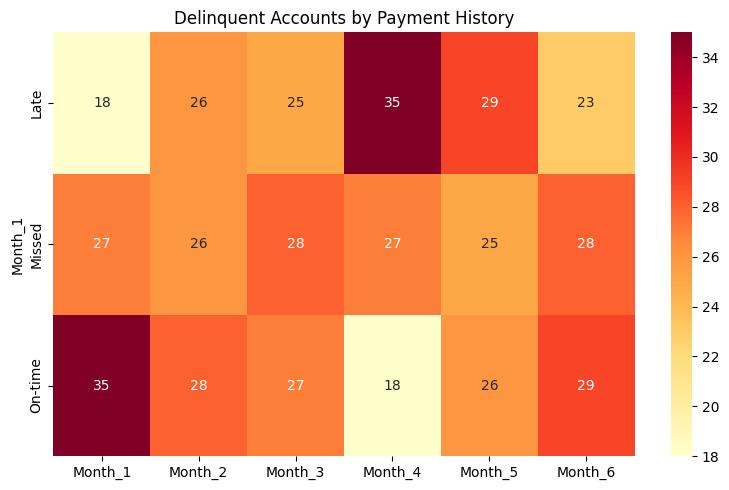

In [48]:
# Plot payment history heatmap

plt.figure(figsize=(8,5))

sns.heatmap(
    payment_summary,
    annot=True,
    cmap="YlOrRd",
    fmt="g"
)

plt.title("Delinquent Accounts by Payment History")

plt.tight_layout()

plt.savefig(
    "images/payment_history_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# Calculate average values by delinquency

grouped = df.groupby(
    "Delinquent_Account"
).mean(numeric_only=True)

grouped

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
Delinquent_Account,,,,,,,,
0,46.11,107306.94,575.15,0.49,2.99,48708.76,0.30,9.84
1,47.10,113902.01,591.15,0.51,2.85,48358.23,0.31,9.20


In [50]:
# Save summary tables

employment_risk.to_csv("employment_risk.csv")

card_risk.to_csv("card_risk.csv")

location_risk.to_csv("location_risk.csv")

grouped.to_csv("average_by_delinquency.csv")

print("Summary tables saved.")

Summary tables saved.


# **Part 5: Data Cleaning, Feature Engineering & Final Dataset**

In [51]:
# Create a copy of the dataset

clean_df = df.copy()

print("Dataset copy created.")

Dataset copy created.


In [52]:
# Fill missing numerical values

clean_df["Income"] = clean_df["Income"].fillna(
    clean_df["Income"].median()
)

clean_df["Loan_Balance"] = clean_df["Loan_Balance"].fillna(
    clean_df["Loan_Balance"].median()
)

clean_df["Credit_Score"] = clean_df["Credit_Score"].fillna(
    clean_df["Credit_Score"].median()
)

In [53]:
# Check remaining missing values

clean_df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,0
Credit_Score,0
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,0
Debt_to_Income_Ratio,0
Employment_Status,0


In [54]:
# Standardize employment status labels

clean_df["Employment_Status"] = (
    clean_df["Employment_Status"]
    .replace({
        "EMP": "Employed",
        "employed": "Employed"
    })
)

clean_df["Employment_Status"].value_counts()

,count
Employment_Status,
Employed,240
Unemployed,93
retired,87
Self-employed,80


In [55]:
# Check credit utilization range

print(
    clean_df["Credit_Utilization"].describe()
)

print()

print(
    "Values above 100%:",
    (clean_df["Credit_Utilization"] > 1).sum()
)

print(
    "Negative values:",
    (clean_df["Credit_Utilization"] < 0).sum()
)

count   500.00
mean      0.49
std       0.20
min       0.05
25%       0.36
50%       0.49
75%       0.63
max       1.03
Name: Credit_Utilization, dtype: float64

Values above 100%: 4
Negative values: 0


In [56]:
# Count missed payments

payment_columns = [
    "Month_1",
    "Month_2",
    "Month_3",
    "Month_4",
    "Month_5",
    "Month_6"
]

clean_df["Missed_Count"] = (
    clean_df[payment_columns] == "Missed"
).sum(axis=1)

clean_df["Missed_Count"].head()

,Missed_Count
0,2
1,3
2,2
3,2
4,2


In [57]:
# Count late payments

clean_df["Late_Count"] = (
    clean_df[payment_columns] == "Late"
).sum(axis=1)

clean_df["Late_Count"].head()

,Late_Count
0,4
1,1
2,3
3,4
4,3


In [58]:
# Count on-time payments

clean_df["On_Time_Count"] = (
    clean_df[payment_columns] == "On-time"
).sum(axis=1)

clean_df["On_Time_Count"].head()

,On_Time_Count
0,0
1,2
2,1
3,0
4,1


In [59]:
# Display engineered features

clean_df[
    [
        "Missed_Count",
        "Late_Count",
        "On_Time_Count"
    ]
].head()

,Missed_Count,Late_Count,On_Time_Count
0,2,4,0
1,3,1,2
2,2,3,1
3,2,4,0
4,2,3,1


In [60]:
# Summary statistics

clean_df[
    [
        "Missed_Count",
        "Late_Count",
        "On_Time_Count"
    ]
].describe()

,Missed_Count,Late_Count,On_Time_Count
count,500.00,500.00,500.00
mean,2.02,2.01,1.97
std,1.12,1.09,1.14
min,0.00,0.00,0.00
25%,1.00,1.00,1.00
50%,2.00,2.00,2.00
75%,3.00,3.00,3.00
max,6.00,6.00,5.00


In [61]:
# Save cleaned dataset

clean_df.to_csv(
    "cleaned_delinquency_dataset.csv",
    index=False
)

print("Cleaned dataset saved.")

Cleaned dataset saved.


In [62]:
# Final dataset information

print("=" * 60)
print("FINAL DATASET")
print("=" * 60)

print(f"Rows : {clean_df.shape[0]}")
print(f"Columns : {clean_df.shape[1]}")

print()

print("Missing Values")

print(clean_df.isnull().sum())

FINAL DATASET
Rows : 500
Columns : 22

Missing Values
Customer_ID             0
Age                     0
Income                  0
Credit_Score            0
Credit_Utilization      0
Missed_Payments         0
Delinquent_Account      0
Loan_Balance            0
Debt_to_Income_Ratio    0
Employment_Status       0
Account_Tenure          0
Credit_Card_Type        0
Location                0
Month_1                 0
Month_2                 0
Month_3                 0
Month_4                 0
Month_5                 0
Month_6                 0
Missed_Count            0
Late_Count              0
On_Time_Count           0
dtype: int64


In [63]:
# Final data quality summary

quality_report = pd.DataFrame({
    "Check": [
        "Duplicate Records",
        "Missing Values",
        "Engineered Features"
    ],
    "Result": [
        clean_df.duplicated().sum(),
        clean_df.isnull().sum().sum(),
        3
    ]
})

quality_report

,Check,Result
0,Duplicate Records,0
1,Missing Values,0
2,Engineered Features,3


In [64]:
# Save quality report

quality_report.to_csv(
    "final_data_quality_report.csv",
    index=False
)

print("Quality report saved.")

Quality report saved.


In [65]:
# Display conclusion

print("=" * 60)
print("EDA CONCLUSION")
print("=" * 60)

print("""
1. The dataset contains 500 customer records.

2. Missing values were identified in Income,
   Loan_Balance, and Credit_Score and were
   imputed using the median.

3. Credit utilization values above 100%
   should be validated before production use.

4. Payment history, credit utilization,
   debt-to-income ratio, and credit score
   appear to be important indicators of
   delinquency risk.

5. Three new behavioral features were
   created:
   - Missed_Count
   - Late_Count
   - On_Time_Count

6. The cleaned dataset is ready for
   predictive modeling.
""")

EDA CONCLUSION

1. The dataset contains 500 customer records.

2. Missing values were identified in Income,
   Loan_Balance, and Credit_Score and were
   imputed using the median.

3. Credit utilization values above 100%
   should be validated before production use.

4. Payment history, credit utilization,
   debt-to-income ratio, and credit score
   appear to be important indicators of
   delinquency risk.

5. Three new behavioral features were
   created:
   - Missed_Count
   - Late_Count
   - On_Time_Count

6. The cleaned dataset is ready for
   predictive modeling.



In [66]:
import os

print(os.listdir("images"))

['correlation_heatmap.png', 'credit_utilization_delinquency.png', 'location_distribution.png', 'credit_score_delinquency.png', 'card_type_distribution.png', 'missing_heatmap.png', 'dti_delinquency.png', 'numerical_distributions.png', 'employment_distribution.png', 'all_boxplots.png', 'missing_values.png', 'employment_delinquency.png', 'payment_history_heatmap.png', 'target_distribution.png']


In [67]:
import shutil

shutil.make_archive("eda_images", "zip", "images")

'/content/eda_images.zip'